In [3]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
spotify = pd.read_csv("/content/spotify_dataset.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## **spotify.head()**
- unnamed indices starting from 0
- track ids seem to be unique long mixed digit letter combinations
- popularity score based on??
- danceability based on?? -> energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, time_signature
- mode seems to take bits as entries

In [9]:
# property/attribute, not method. no ()
spotify.shape

(114000, 21)

## **spotify.shape**
- rows: 114,000
- cols: 21

In [11]:
spotify.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

## **spotify.columns**
full list of cols to work with:
'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'

In [12]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## **spotify.info()**
- artists, album_name, track_name contain 1 null each
- 1 bool col, 9 float64 cols, 6 int64 cols, 5 generic object cols

In [14]:
spotify.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## **spotify.describe()**
- only displays columns of numeric data type ie. float64, int64 hence only 15 cols.
- songs can have 0 popularity -- completely unlistened to songs? -- only connections = artist, listeners (don't have access) -- what makes a song have max (100) popularity?

In [15]:
spotify.track_genre.value_counts()

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
trance,1000
trip-hop,1000


## **spotify.track_genre.value_counts()**
- 1000 songs of each genre, uniform dataset

In [7]:
spotify.groupby('artists')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
artists,,
Sam Smith;Kim Petras,100.0,2
Bizarrap;Quevedo,99.0,1
Manuel Turizo,98.0,4
Bad Bunny;Chencho Corleone,97.0,4
Bad Bunny;Bomba Estéreo,94.5,4
...,...,...
Sergei Lemeshev;Andrey Semjonov;Il'ja Mar'in,0.0,1
Almklausi;Specktakel,0.0,2
Alok;Axel Cooper;Stefy De Cicco,0.0,2


In [8]:
spotify.track_id.duplicated().sum()

np.int64(21064)

<Axes: xlabel='popularity', ylabel='Count'>

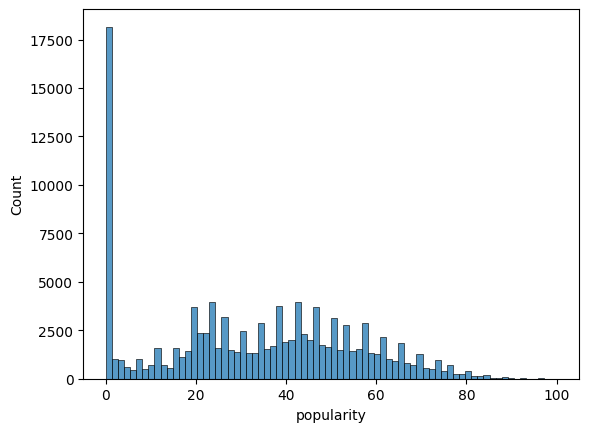

In [14]:
# standard histogram
spotify_hist = sns.histplot(data=spotify, x='popularity')

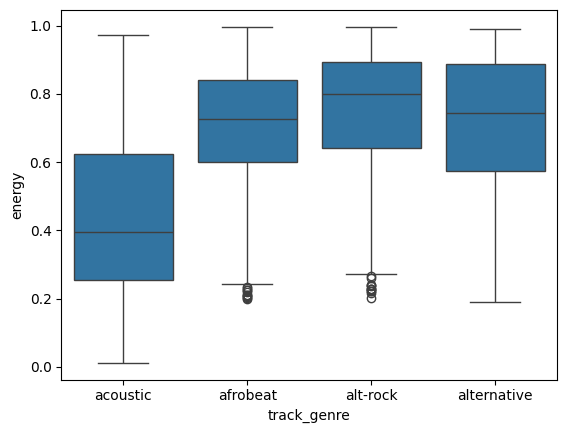

In [4]:
#standard boxplot, usually want specific genres
spotify['track_genre'].unique()
spotify_box = sns.boxplot(data=spotify[spotify.track_genre.isin(['acoustic', 'afrobeat', 'alt-rock', 'alternative'])], x='track_genre', y='energy')

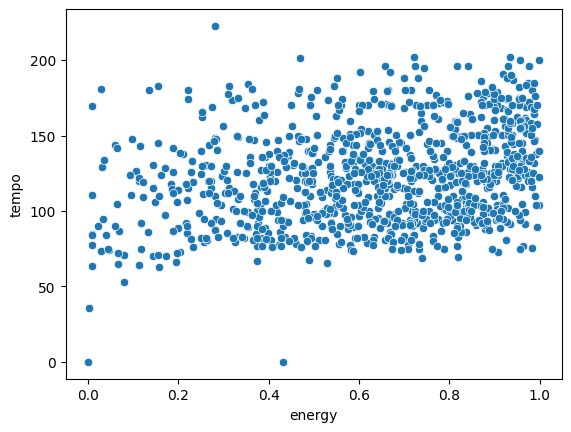

In [30]:
# standard scatterplot between two numerics
spotify_scatter = sns.scatterplot(data=spotify.sample(1000), x='energy', y='tempo')

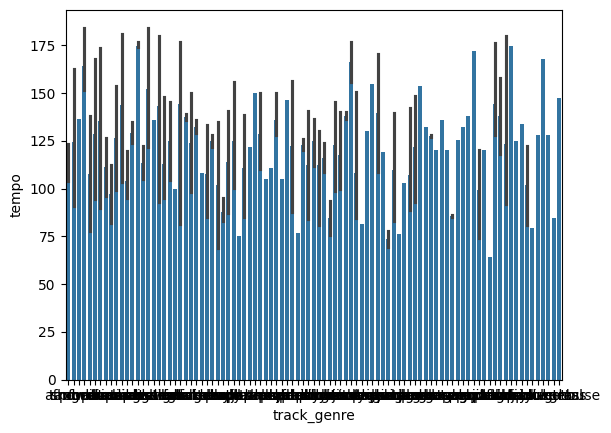

In [33]:
# standard barplot between two categories
spotify_bar = sns.barplot(data=spotify.sample(200), x='track_genre', y='tempo')

<Axes: xlabel='energy', ylabel='acousticness'>

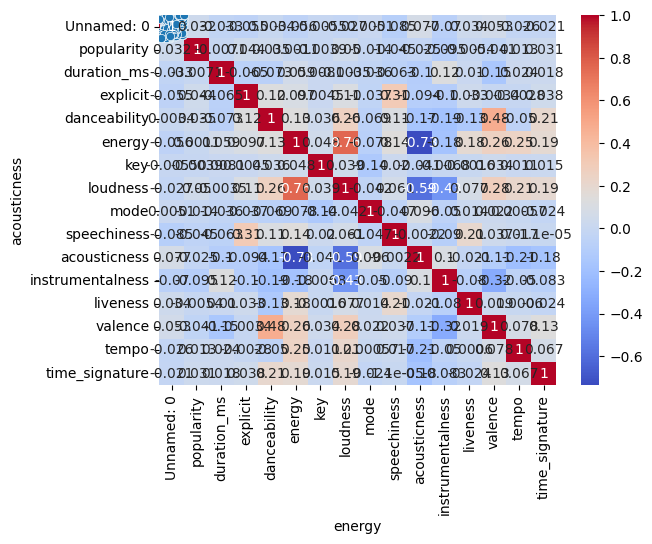

In [4]:
# heatmap -> indicates no real correlation between song characteristics and popularity; answers question: can song audio features be used
# to predict the popularity of a song? -> no.
corr = spotify.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
# strongest correlations: (energy, acousticness) -> inverse, (loudness, acousticness) -> inverse

<Axes: xlabel='energy', ylabel='acousticness'>

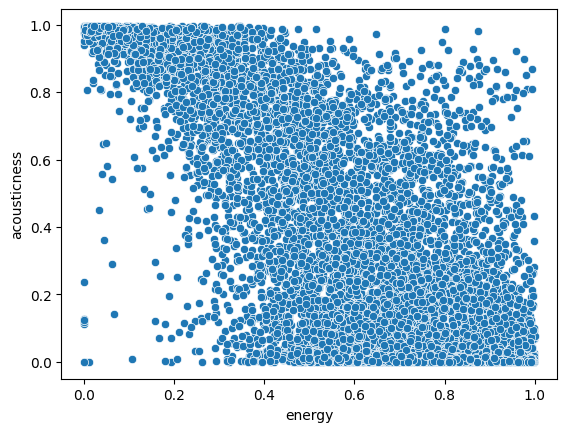

In [6]:
sns.scatterplot(data=spotify.sample(10000), x='energy', y='acousticness')

<Axes: xlabel='loudness', ylabel='acousticness'>

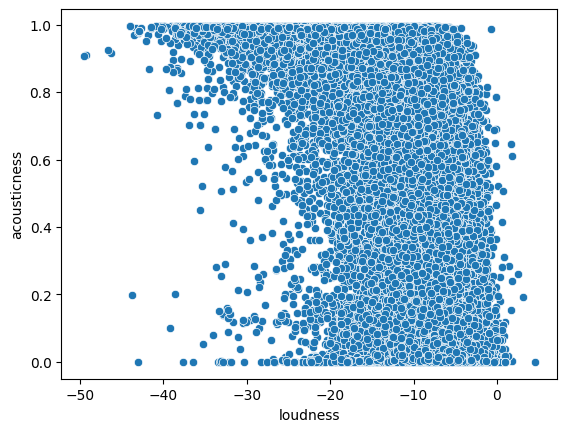

In [15]:
sns.scatterplot(data=spotify, x='loudness', y='acousticness')